# Demystifying Model Behavior: From Genetic Risk to Binary Classification

Welcome to this interactive notebook! In this space, we are going to explore exactly how machine learning models and explainability tools behave when we shift the underlying "ground truth" of categorical data predicting a categorical outcome. 

In the real world of clinical genomics and bioinformatics, we often feed discrete data (like genotypes coded as 0, 1, and 2) into an algorithm like XGBoost to predict a **binary outcome**—such as whether a patient has a specific disease or not (coded as 1 or 0). But how do we know *what* the model is actually learning? To answer this, we are going to play the role of the "Creator." We will generate synthetic datasets where **we know the exact biological and probabilistic mechanisms** governing the binary target ($y$). 

By knowing the absolute, indisputable truth, we can test how well Traditional Statistics (Chi-Square & Logistic Regression) and Machine Learning (XGBoost Classifier + SHAP) uncover that truth across three increasingly realistic clinical scenarios.

## The Three Scenarios We Will Explore

We will run an end-to-end analytical pipeline—training, evaluating, and explaining—on the following three cases:

### Case 1: The Simple Logistic World (Pure Main Effects)
* **The Reality:** The binary target $y$ (Disease vs. Healthy) is driven by independent genes acting alone. These genes increase or decrease the hidden "latent risk" (log-odds) of the disease. This risk is then converted into a probability using a sigmoid function, and nature rolls the dice (a binomial distribution) to assign the final 0 or 1.
* **The Goal:** Establish a baseline. We will see how perfectly traditional methods handle simple categorical-to-categorical relationships. We will test if a simple bivariate test (Chi-Square) flags the right genes, how multivariate Logistic Regression captures the true log-odds weights, and how XGBoost + SHAP represent main effects in a probability space.

### Case 2: The Complex Biological World (Epistatic Interactions)
* **The Reality:** Biology is rarely strictly independent; features now interact with one another to influence the log-odds of the disease (e.g., Gene A only increases disease risk if Gene B is also mutated, known as epistasis). 
* **The Goal:** Observe the divergence between traditional stats and machine learning. A standard Chi-Square test evaluates genes one by one and might miss interacting pairs, while Logistic Regression will struggle without manual interaction terms. Conversely, XGBoost's tree structure will naturally map the combinations. We will use SHAP interaction values to crack open the model and visualize exactly how these genes are working together.

### Case 3: The Incomplete World (Missing Heritability / Hidden Features)
* **The Reality:** We generate a complex dataset with interactions, but deliberately *hide* critical contributing genes or environmental factors from the model. 
* **The Goal:** Mimic messy, real-world clinical scenarios where we simply lack all the necessary data. We will watch our classification evaluation metrics (like Accuracy, ROC AUC, and Log Loss) degrade, and use SHAP to see how the model tries (and often fails) to compensate for the missing puzzle pieces.

## Our Toolkit
To accomplish this, we will be utilizing:
* **Custom Generators:** `numpy` and `pandas` to build the exact latent log-odds equations, apply sigmoid probabilities, and sample categorical binomial outcomes.
* **Baseline Modeling:** `scipy.stats` (Chi-Square) for bivariate independence testing, and `statsmodels` (Logistic Regression) for traditional multivariate statistical significance.
* **Predictive Modeling:** `xgboost` (XGBClassifier) to natively handle categorical data and capture non-linear step functions and complex interactions for binary targets.
* **Explainability:** `shap` (SHapley Additive exPlanations) to trace global feature importance, visualize specific biological distributions in log-odds space via violin plots, and isolate pure variable interactions.

In [1]:
from XAI_test_3 import *

## simple linear combination test

### make example data 1

In [2]:

# 1. Generate Binary Data
X, _, y_binary, visible_features, _ = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(0, 0), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (-1.44 * Feature_3 [dominant]) + 
  (-1.34 * Feature_6 [dominant]) + 
  (-0.19 * Feature_9 [dominant]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_6: p-value = 2.9498e-65
  - Feature_3: p-value = 7.1275e-42


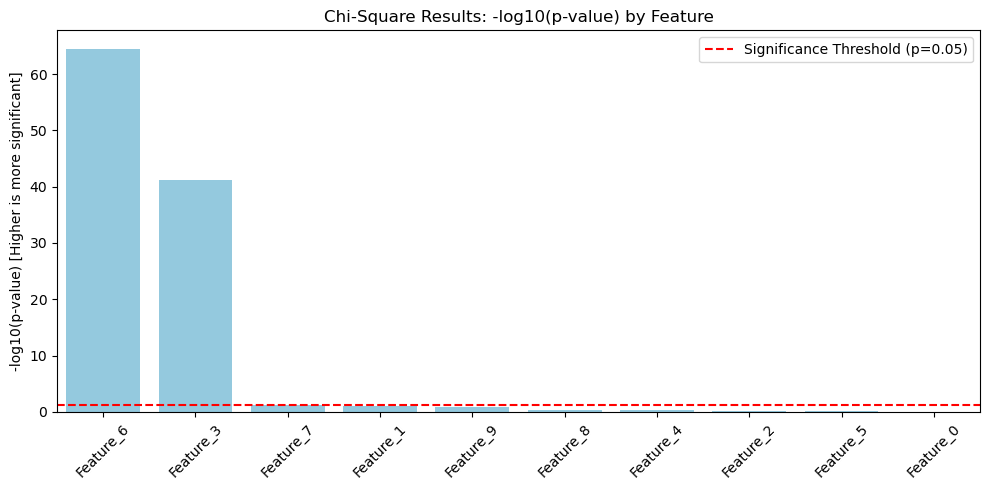

Chi-Square Significant Features: [('Feature_6', 2.949807987237891e-65), ('Feature_3', 7.127463379139808e-42), ('Feature_7', 0.05588718685889786), ('Feature_1', 0.10343777116191119), ('Feature_9', 0.11063238187587163), ('Feature_8', 0.40810856626987424), ('Feature_4', 0.5474783908769005), ('Feature_2', 0.5902493275459879), ('Feature_5', 0.8054595065094863), ('Feature_0', 0.8433403340475594)]


In [3]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
chi_square_features = perform_traditional_chi_square(X_train, y_train)

print("Chi-Square Significant Features:", chi_square_features)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1001
Time:                        15:10:07   Log-Likelihood:                -2108.4
converged:                       True   LL-Null:                       -2342.9
Covariance Type:            nonrobust   LLR p-value:                 1.863e-94
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0395      0.093     -0.423      0.672      -0.223       0.143
Feature_0      0.0421      0.062      0.677      0.498      -0.08

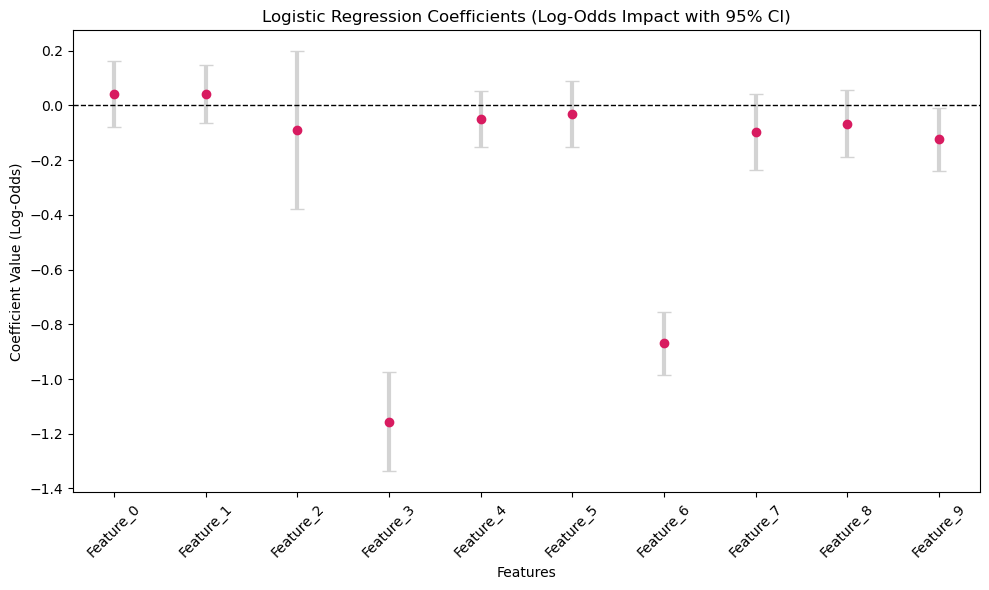

Logistic Regression Significant Features: ['Feature_3', 'Feature_6', 'Feature_9']


In [4]:

# 2b. Traditional Baseline 2 (Logistic Regression)
logistic_model, logistic_features = perform_traditional_logistic_regression(X_train, y_train)

print("Logistic Regression Significant Features:", logistic_features)


### make a simple xgboost model for test 1

In [5]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.7480
ROC AUC:  0.7406
Log Loss: 0.4987



### look at XGBoost Native Importances

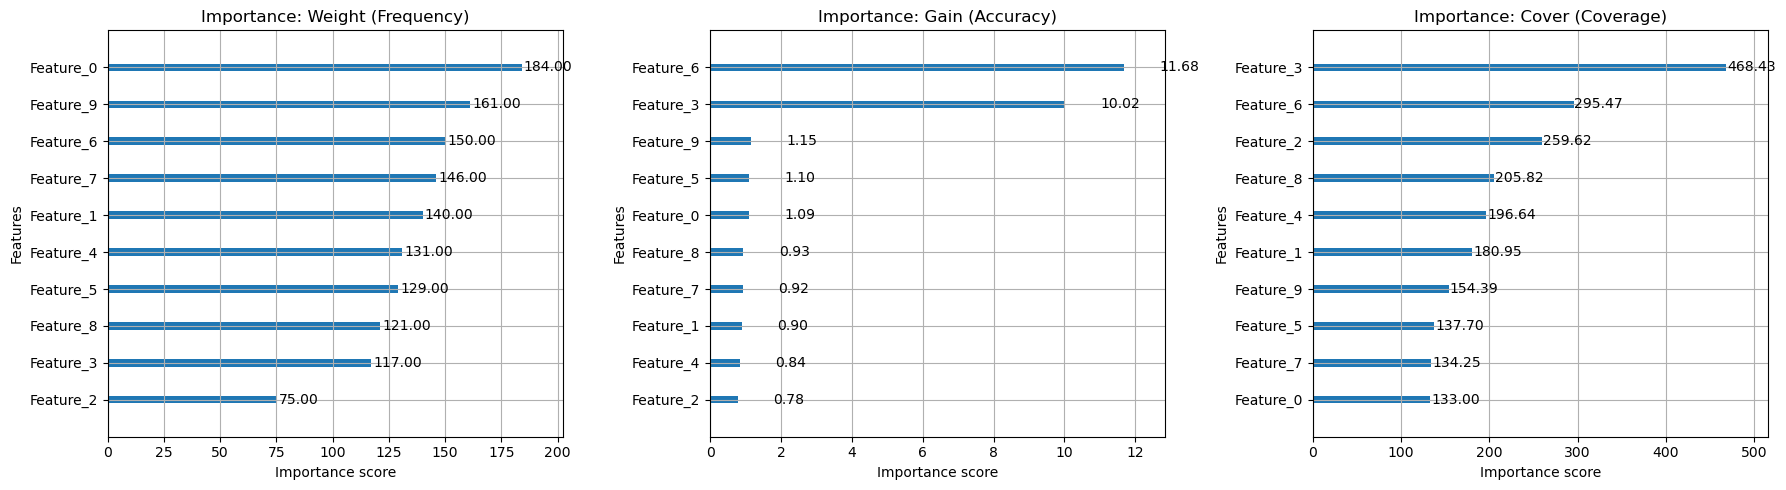

XGBoost Weight Importance: {'Feature_0': 184.0, 'Feature_1': 140.0, 'Feature_2': 75.0, 'Feature_3': 117.0, 'Feature_4': 131.0, 'Feature_5': 129.0, 'Feature_6': 150.0, 'Feature_7': 146.0, 'Feature_8': 121.0, 'Feature_9': 161.0}
XGBoost Gain Importance: {'Feature_0': 1.0895155668258667, 'Feature_1': 0.9031069874763489, 'Feature_2': 0.77652508020401, 'Feature_3': 10.020359992980957, 'Feature_4': 0.8406321406364441, 'Feature_5': 1.1011536121368408, 'Feature_6': 11.680061340332031, 'Feature_7': 0.9235796928405762, 'Feature_8': 0.9345967769622803, 'Feature_9': 1.1519367694854736}
XGBoost Cover Importance: {'Feature_0': 132.9967041015625, 'Feature_1': 180.95361328125, 'Feature_2': 259.6189880371094, 'Feature_3': 468.42694091796875, 'Feature_4': 196.63975524902344, 'Feature_5': 137.7022705078125, 'Feature_6': 295.4728698730469, 'Feature_7': 134.25494384765625, 'Feature_8': 205.8189697265625, 'Feature_9': 154.38943481445312}


In [6]:

# 5.2. XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [7]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

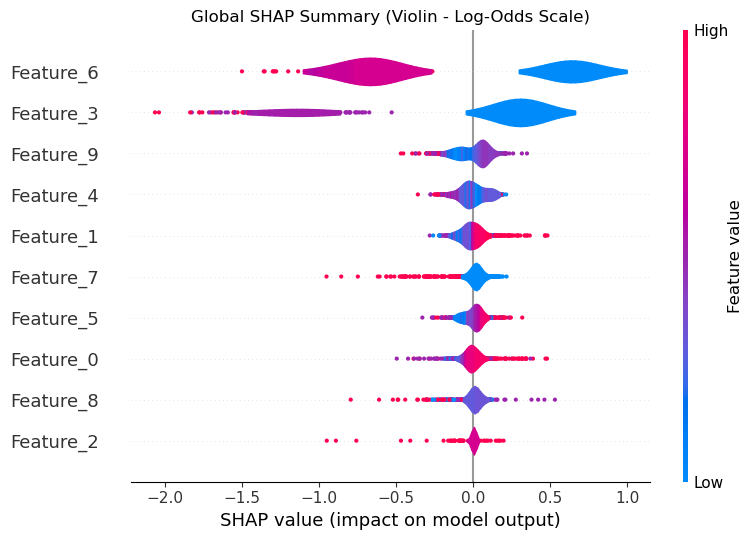

In [8]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


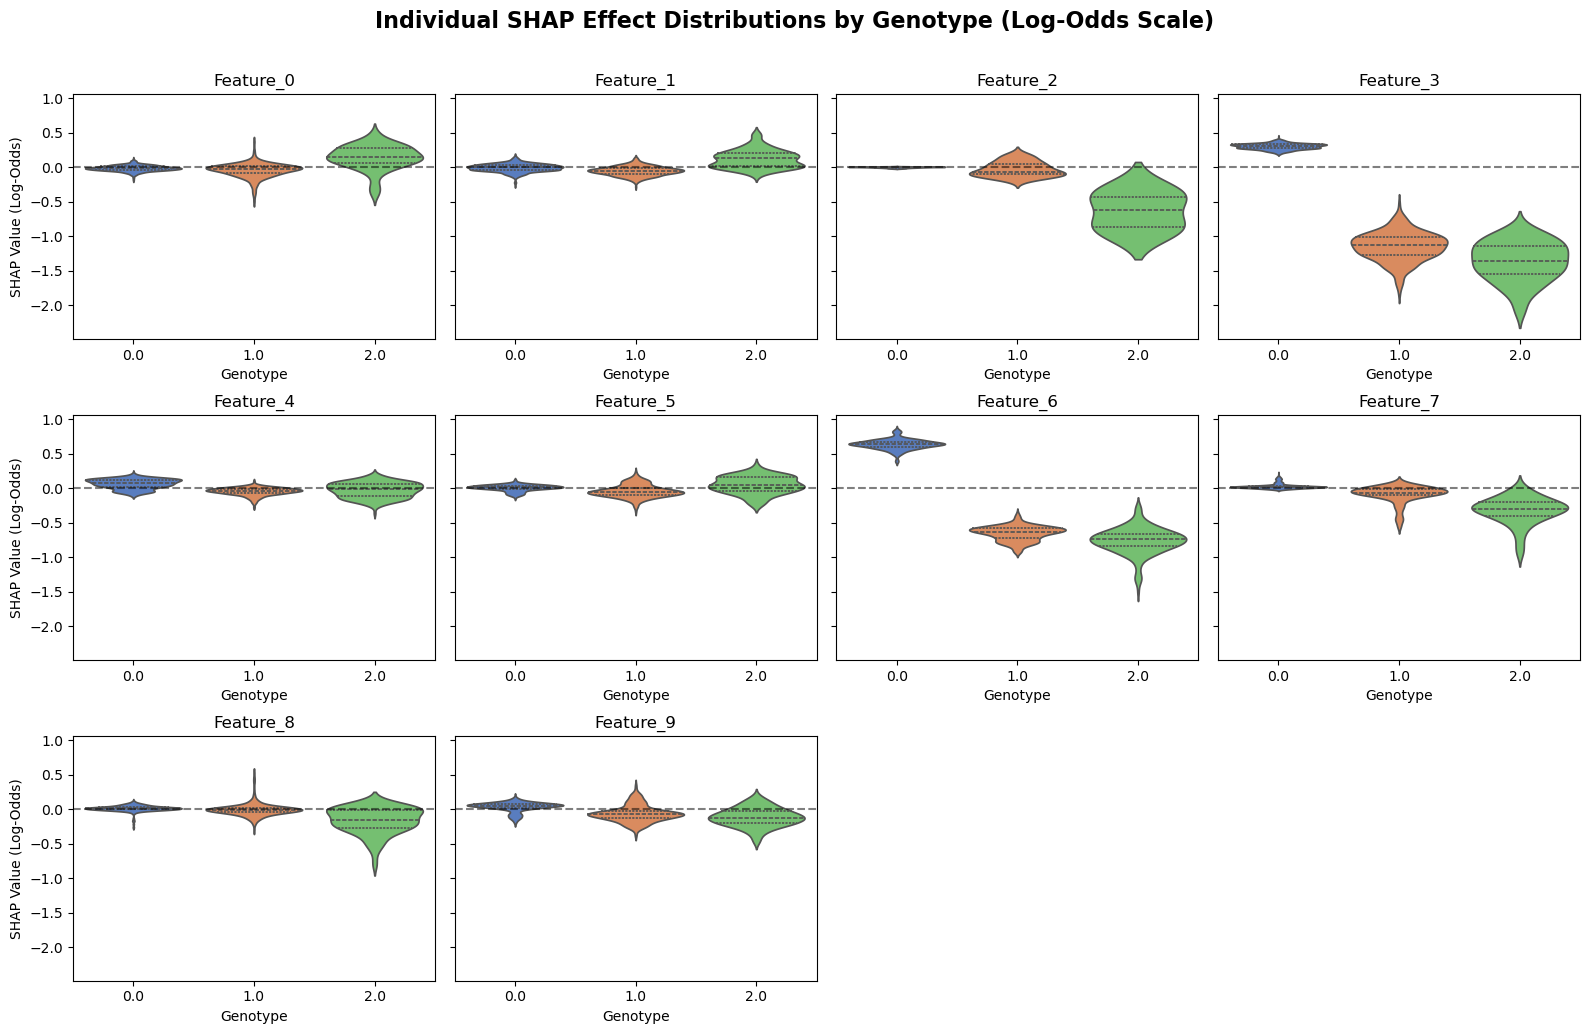

In [9]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


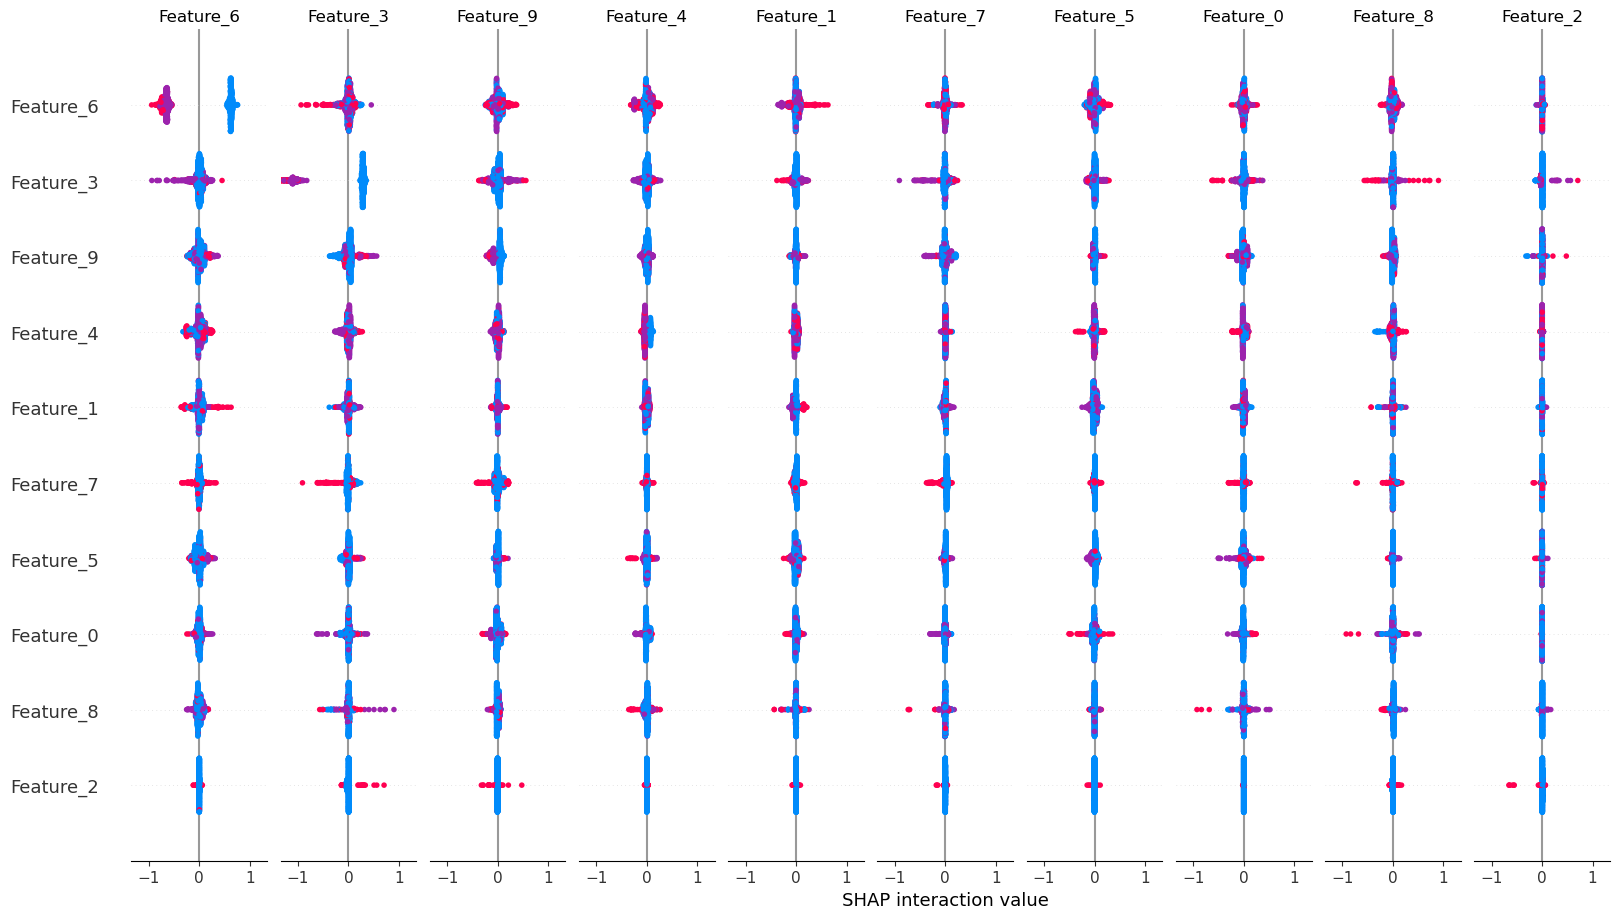


Strongest Interaction found by SHAP: Feature_4 & Feature_6
Plotting pure interaction effect for Feature_4 and Feature_6...


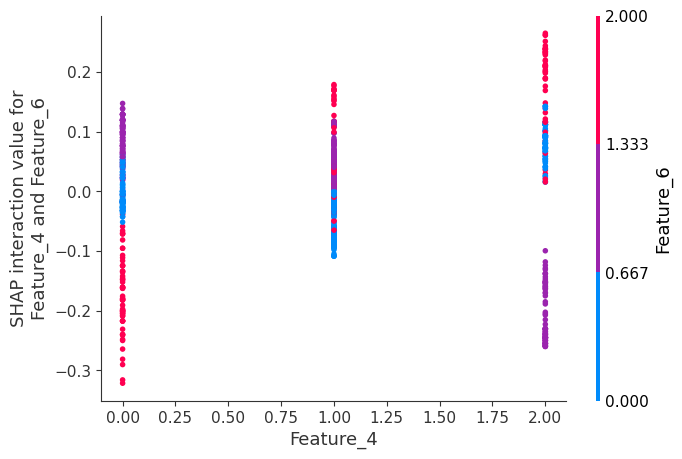


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_4 * Feature_6: 0.076005
  Feature_3 * Feature_9: 0.074208
  Feature_6 * Feature_9: 0.071977
  Feature_3 * Feature_6: 0.064891
  Feature_1 * Feature_6: 0.059542
  Feature_5 * Feature_6: 0.055920
  Feature_3 * Feature_7: 0.052633
  Feature_7 * Feature_9: 0.044208
  Feature_3 * Feature_4: 0.043417
  Feature_6 * Feature_8: 0.039848
-------------------------------------------------

Interaction Effects:
 {'Feature_4 * Feature_6': 0.0760047510266304, 'Feature_3 * Feature_9': 0.07420828938484192, 'Feature_6 * Feature_9': 0.07197663187980652, 'Feature_3 * Feature_6': 0.06489138305187225, 'Feature_1 * Feature_6': 0.05954193323850632, 'Feature_5 * Feature_6': 0.055920183658599854, 'Feature_3 * Feature_7': 0.05263293534517288, 'Feature_7 * Feature_9': 0.04420791566371918, 'Feature_3 * Feature_4': 0.043417464941740036, 'Feature_6 * Feature_8': 0.039848148822784424, 'Feature_0 * Feature_9': 0.0389171727001

In [10]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)

#### SHAP summry

In [11]:

# Print numerical ranking
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_6              0.668125     0.0    405   0.638197  0.073265  0.380130  0.603083     0.641502  0.675145  0.857014
Feature_6              0.668125     1.0    395  -0.652007  0.106493 -0.933317 -0.722188    -0.633344 -0.579095 -0.359515
Feature_6              0.668125     2.0    200  -0.760563  0.191209 -1.501683 -0.841005    -0.740896 -0.657423 -0.265589
Feature_3              0.557659     0.0    712   0.304145  0.041527  0.191715  0.275842     0.306401  0.334736  0.442573
Feature_3              0.557659     1.0    237  -1.145830  0.208348 -1.826806 -1.275460    -1.127736 -1.004627 -0.530075
Feature_3              0.557659     2.0     51  -1.363659  0.284537 -2.066097 -1.549113    -1.356870 -1.145647 -0.894746
Feature_9              0.088856     0.0    601   0.034636  0.069731 -0.213719  0.015414     0.05

## test for linear combination with some feature interactions

### make example data 2

In [12]:

# 1. Generate Binary Data
X, _, y_binary, visible_features, _ = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (1.46 * Feature_8 [additive]) + 
  (-1.26 * Feature_2 [dominant]) + 
  (1.03 * Feature_9 [additive]) + 
  (0.59 * Feature_0 [recessive]) + 
  (-0.39 * Feature_3 [dominant]) + 
  (1.42 * (Feature_3, Feature_6) [xor_interference]) + 
  (-0.38 * (Feature_2, Feature_9) [multiplicative]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_2: p-value = 1.9132e-43
  - Feature_9: p-value = 2.0852e-35
  - Feature_8: p-value = 4.7815e-21
  - Feature_3: p-value = 3.3396e-03


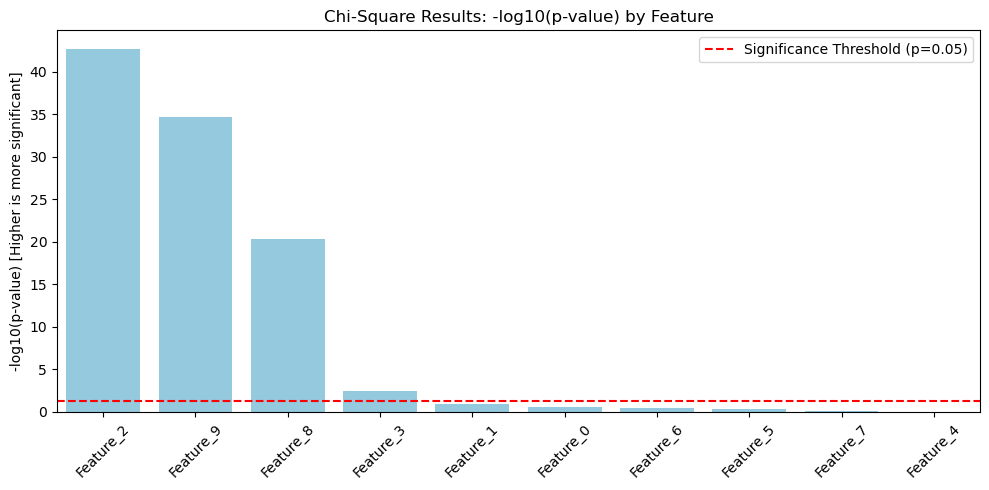

Chi-Square Significant Features: [('Feature_2', 1.913242565165894e-43), ('Feature_9', 2.0852465611717796e-35), ('Feature_8', 4.781491675629983e-21), ('Feature_3', 0.0033396224062018196), ('Feature_1', 0.11394402942652727), ('Feature_0', 0.25409588013479883), ('Feature_6', 0.38355485952046203), ('Feature_5', 0.42611261262440003), ('Feature_7', 0.8817419357166658), ('Feature_4', 0.9973079067782232)]


In [13]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
chi_square_features = perform_traditional_chi_square(X_train, y_train)

print("Chi-Square Significant Features:", chi_square_features)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.09315
Time:                        15:10:17   Log-Likelihood:                -2296.6
converged:                       True   LL-Null:                       -2532.4
Covariance Type:            nonrobust   LLR p-value:                 4.703e-95
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4119      0.085      4.872      0.000       0.246       0.578
Feature_0      0.1262      0.081      1.552      0.121      -0.03

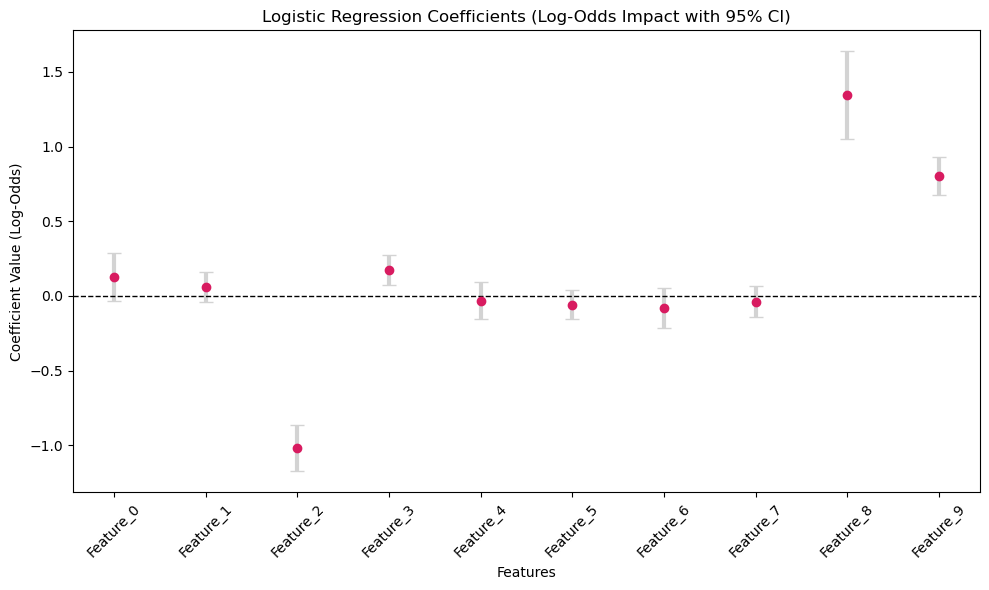

Logistic Regression Significant Features: ['Feature_2', 'Feature_3', 'Feature_8', 'Feature_9']


In [14]:

# 2b. Traditional Baseline 2 (Logistic Regression)
logistic_model, logistic_features = perform_traditional_logistic_regression(X_train, y_train)

print("Logistic Regression Significant Features:", logistic_features)


### make a simple xgboost model for test 2

In [15]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.7170
ROC AUC:  0.7433
Log Loss: 0.5547



### look at XGBoost Native Importances

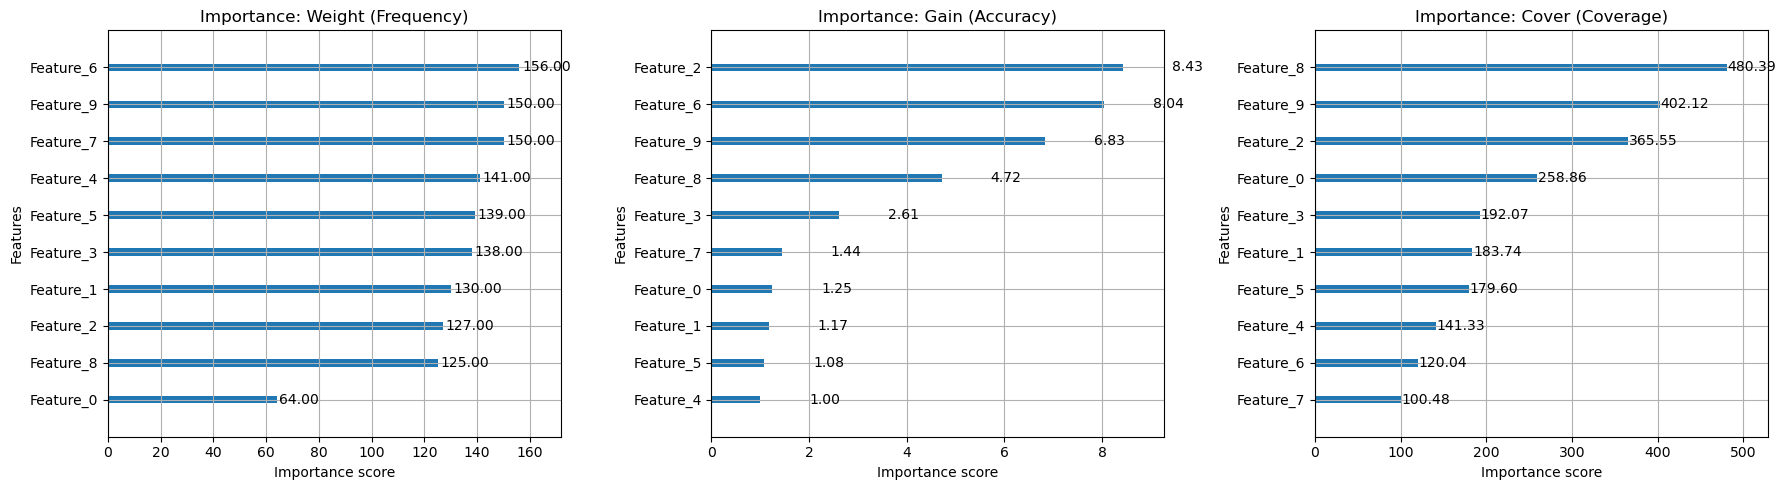

XGBoost Weight Importance: {'Feature_0': 64.0, 'Feature_1': 130.0, 'Feature_2': 127.0, 'Feature_3': 138.0, 'Feature_4': 141.0, 'Feature_5': 139.0, 'Feature_6': 156.0, 'Feature_7': 150.0, 'Feature_8': 125.0, 'Feature_9': 150.0}
XGBoost Gain Importance: {'Feature_0': 1.2500814199447632, 'Feature_1': 1.1742708683013916, 'Feature_2': 8.431678771972656, 'Feature_3': 2.6134541034698486, 'Feature_4': 0.9994776248931885, 'Feature_5': 1.0833593606948853, 'Feature_6': 8.040669441223145, 'Feature_7': 1.437084674835205, 'Feature_8': 4.723191738128662, 'Feature_9': 6.834374904632568}
XGBoost Cover Importance: {'Feature_0': 258.8648376464844, 'Feature_1': 183.73968505859375, 'Feature_2': 365.553955078125, 'Feature_3': 192.06983947753906, 'Feature_4': 141.3323211669922, 'Feature_5': 179.60235595703125, 'Feature_6': 120.0386734008789, 'Feature_7': 100.48291778564453, 'Feature_8': 480.39410400390625, 'Feature_9': 402.1158447265625}


In [16]:

# 5.2. XGBoost Importances

weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)



### try to use SHAP to find the influencing inputs

In [17]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

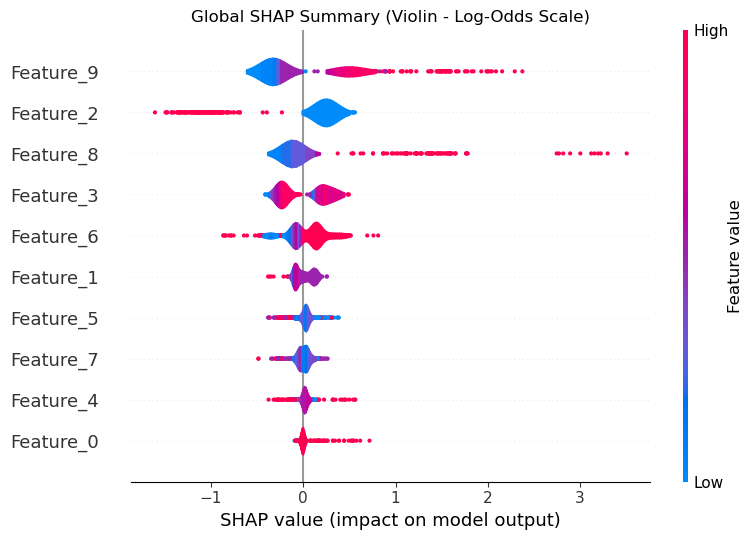

In [18]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


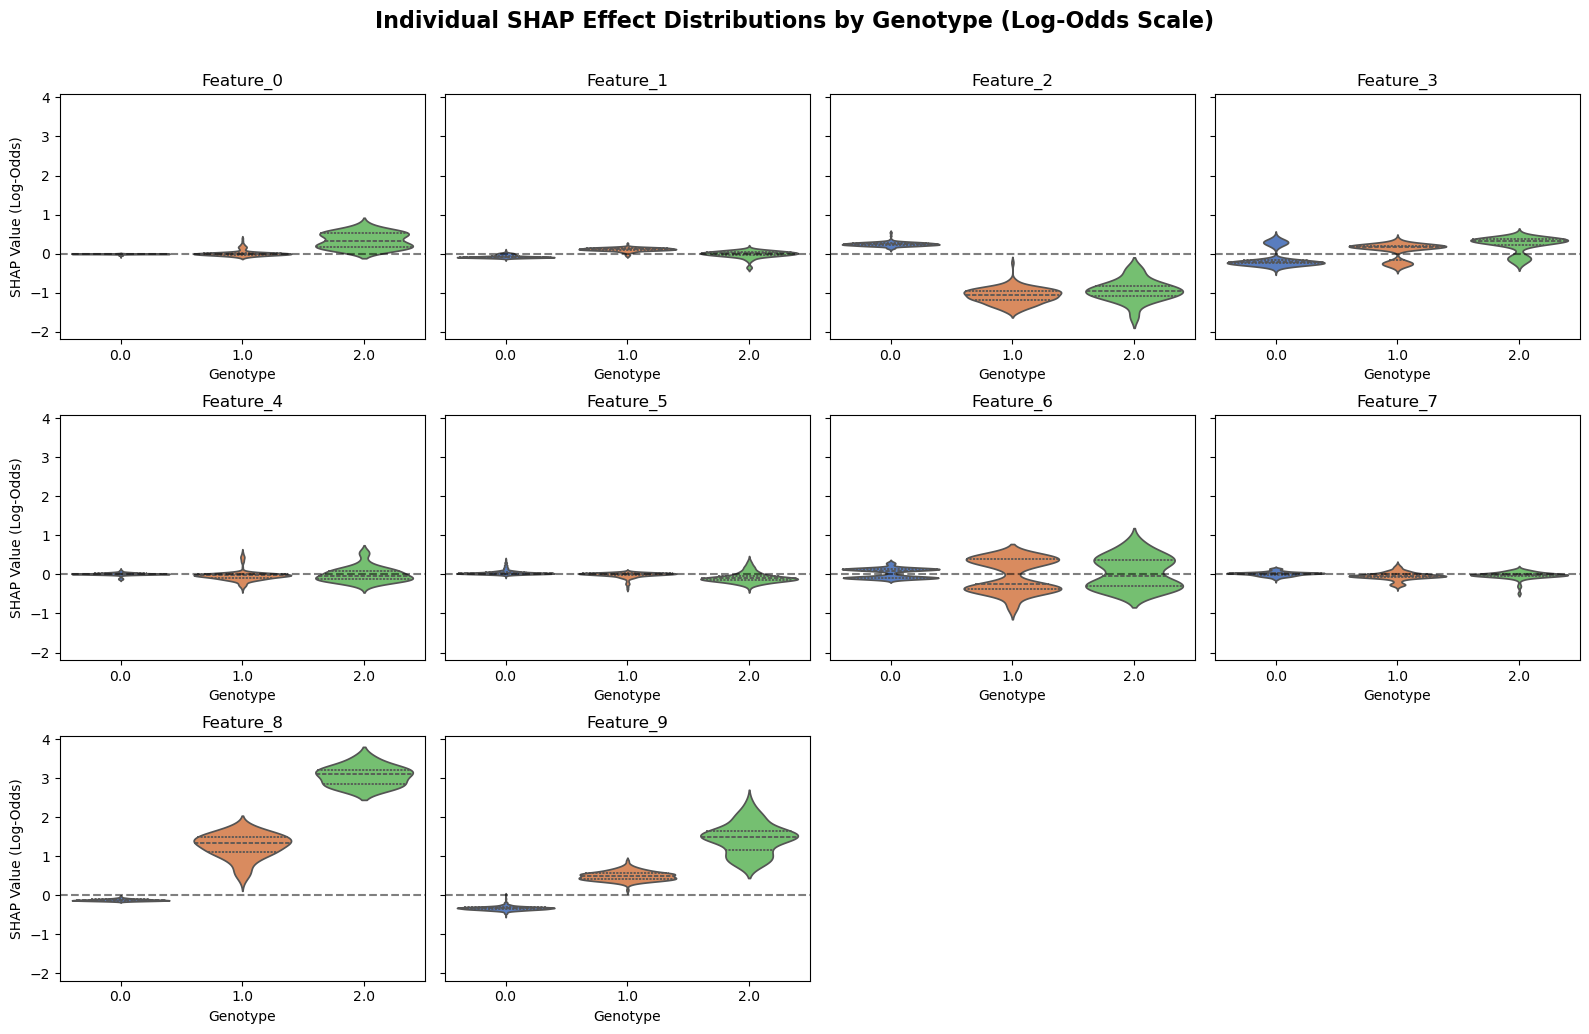

In [19]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


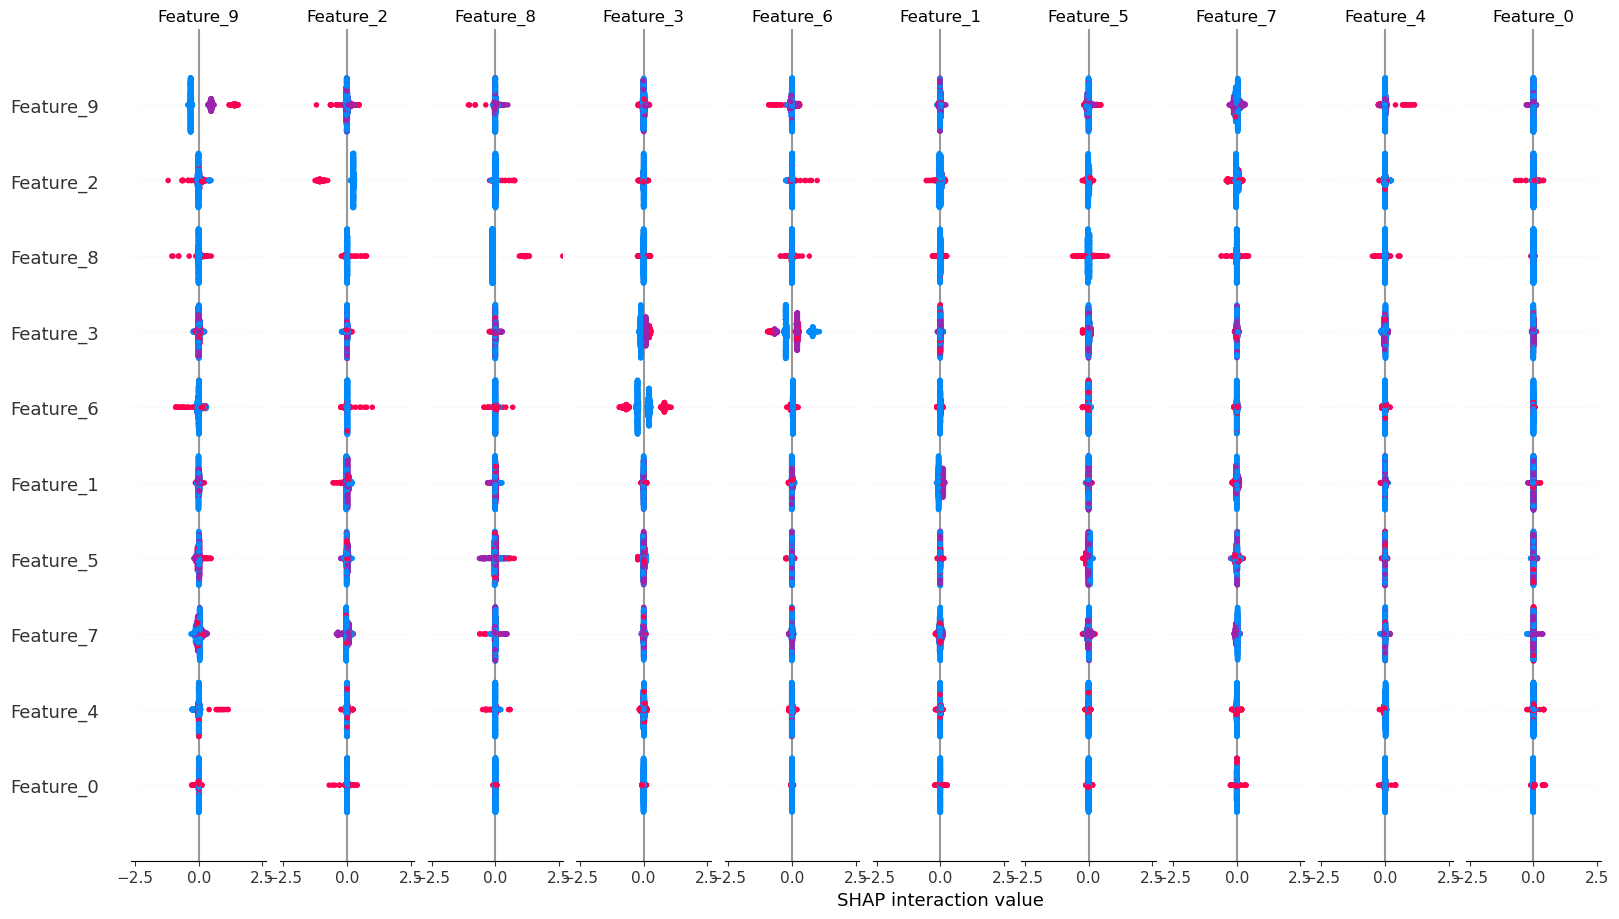


Strongest Interaction found by SHAP: Feature_3 & Feature_6
Plotting pure interaction effect for Feature_3 and Feature_6...


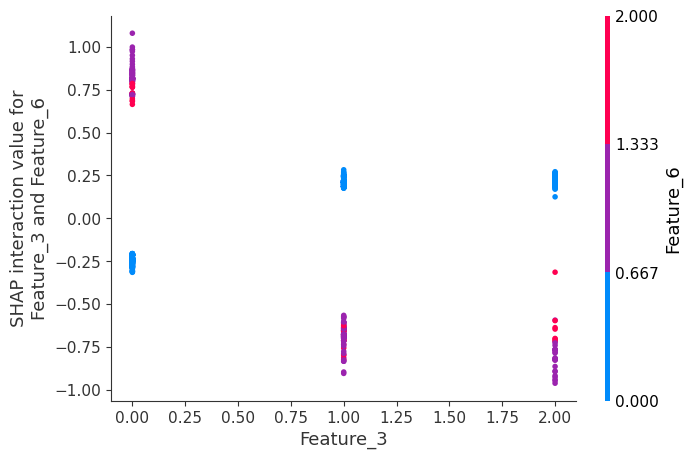


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_3 * Feature_6: 0.352896
  Feature_7 * Feature_9: 0.071842
  Feature_2 * Feature_7: 0.057901
  Feature_5 * Feature_8: 0.054706
  Feature_6 * Feature_9: 0.049209
  Feature_2 * Feature_9: 0.048257
  Feature_1 * Feature_2: 0.040887
  Feature_4 * Feature_9: 0.040496
  Feature_5 * Feature_9: 0.037480
  Feature_5 * Feature_7: 0.036075
-------------------------------------------------

Interaction Effects:
 {'Feature_3 * Feature_6': 0.35289645195007324, 'Feature_7 * Feature_9': 0.07184162735939026, 'Feature_2 * Feature_7': 0.05790127441287041, 'Feature_5 * Feature_8': 0.05470648035407066, 'Feature_6 * Feature_9': 0.04920942336320877, 'Feature_2 * Feature_9': 0.048256777226924896, 'Feature_1 * Feature_2': 0.0408872589468956, 'Feature_4 * Feature_9': 0.040496233850717545, 'Feature_5 * Feature_9': 0.03747976943850517, 'Feature_5 * Feature_7': 0.036075081676244736, 'Feature_8 * Feature_9': 0.0311432741582

In [20]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [21]:

# Print numerical ranking
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_9              0.457697     0.0    641  -0.328082  0.050029 -0.531865 -0.356607    -0.326744 -0.305096  0.026100
Feature_9              0.457697     1.0    289   0.502491  0.116121  0.121271  0.419338     0.496184  0.571647  0.887626
Feature_9              0.457697     2.0     70   1.458924  0.385186  0.772789  1.160821     1.497699  1.640391  2.374203
Feature_2              0.376432     0.0    841   0.246853  0.052853  0.085997  0.218776     0.243439  0.274938  0.560272
Feature_2              0.376432     1.0    139  -1.078945  0.193271 -1.491911 -1.199576    -1.073608 -0.954015 -0.230722
Feature_2              0.376432     2.0     20  -0.942757  0.270175 -1.605847 -1.075144    -0.958216 -0.824306 -0.393821
Feature_8              0.246205     0.0    905  -0.117270  0.024119 -0.174971 -0.133442    -0.12

## test for addition of hidden features

### make example data 3

In [22]:

# 1. Generate Binary Data
X, X_hidden, y_binary, visible_features, hidden_features = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(1, 2), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=True,           
    hidden_in_interactions=True,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (-1.50 * Feature_9 [dominant]) + 
  (1.44 * Feature_6 [recessive]) + 
  (0.89 * Hidden_0 [additive]) + 
  (0.59 * Feature_8 [additive]) + 
  (0.03 * Feature_1 [additive]) + 
  (-0.96 * (Feature_2, Feature_4) [dominant_epistasis]) + 
  (-0.90 * (Feature_3, Hidden_0) [recessive_epistasis]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_9: p-value = 2.1119e-79
  - Feature_6: p-value = 3.8298e-29
  - Feature_8: p-value = 4.3094e-08
  - Feature_4: p-value = 1.9752e-02


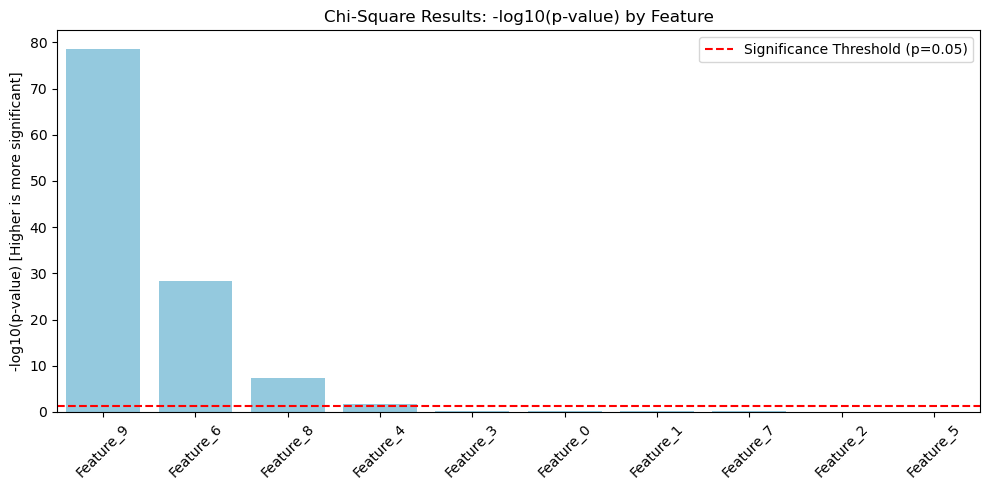

Chi-Square Significant Features: [('Feature_9', 2.1118661233642794e-79), ('Feature_6', 3.829849133508921e-29), ('Feature_8', 4.309368745059724e-08), ('Feature_4', 0.019751722128407322), ('Feature_3', 0.4920674720901922), ('Feature_0', 0.6071967638370627), ('Feature_1', 0.6343674853386663), ('Feature_7', 0.7477243018841524), ('Feature_2', 0.8687147842091056), ('Feature_5', 0.8965184416708238)]


In [23]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
chi_square_features = perform_traditional_chi_square(X_train, y_train)

print("Chi-Square Significant Features:", chi_square_features)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.07788
Time:                        15:10:28   Log-Likelihood:                -2492.8
converged:                       True   LL-Null:                       -2703.4
Covariance Type:            nonrobust   LLR p-value:                 3.050e-84
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0805      0.084     -0.953      0.340      -0.246       0.085
Feature_0      0.0501      0.082      0.610      0.542      -0.11

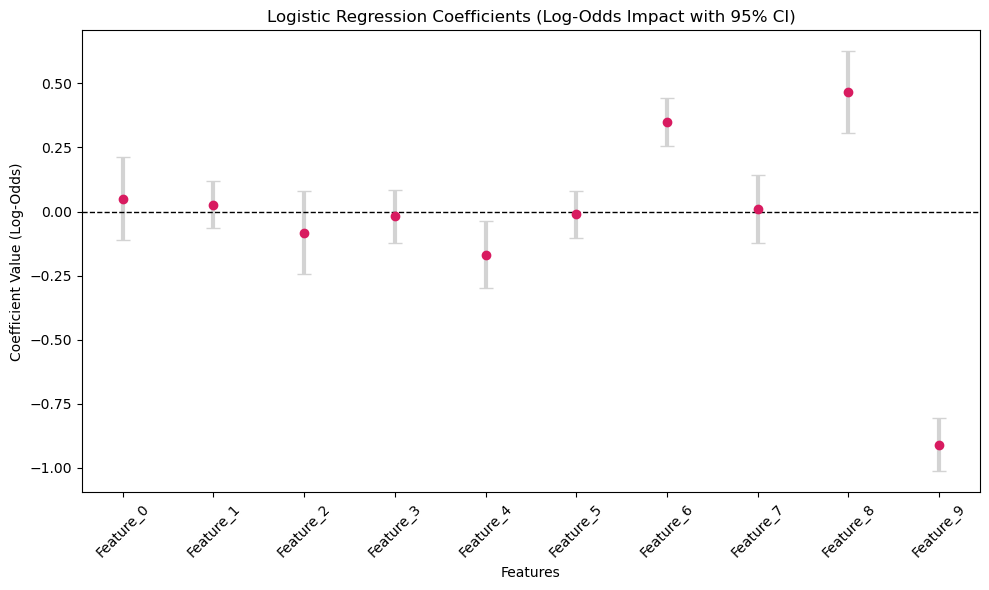

Logistic Regression Significant Features: ['Feature_4', 'Feature_6', 'Feature_8', 'Feature_9']


In [24]:

# 2b. Traditional Baseline 2 (Logistic Regression)
logistic_model, logistic_features = perform_traditional_logistic_regression(X_train, y_train)

print("Logistic Regression Significant Features:", logistic_features)


### make a simple xgboost model for test 3

In [25]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.6290
ROC AUC:  0.6804
Log Loss: 0.6391



### look at XGBoost Native Importances

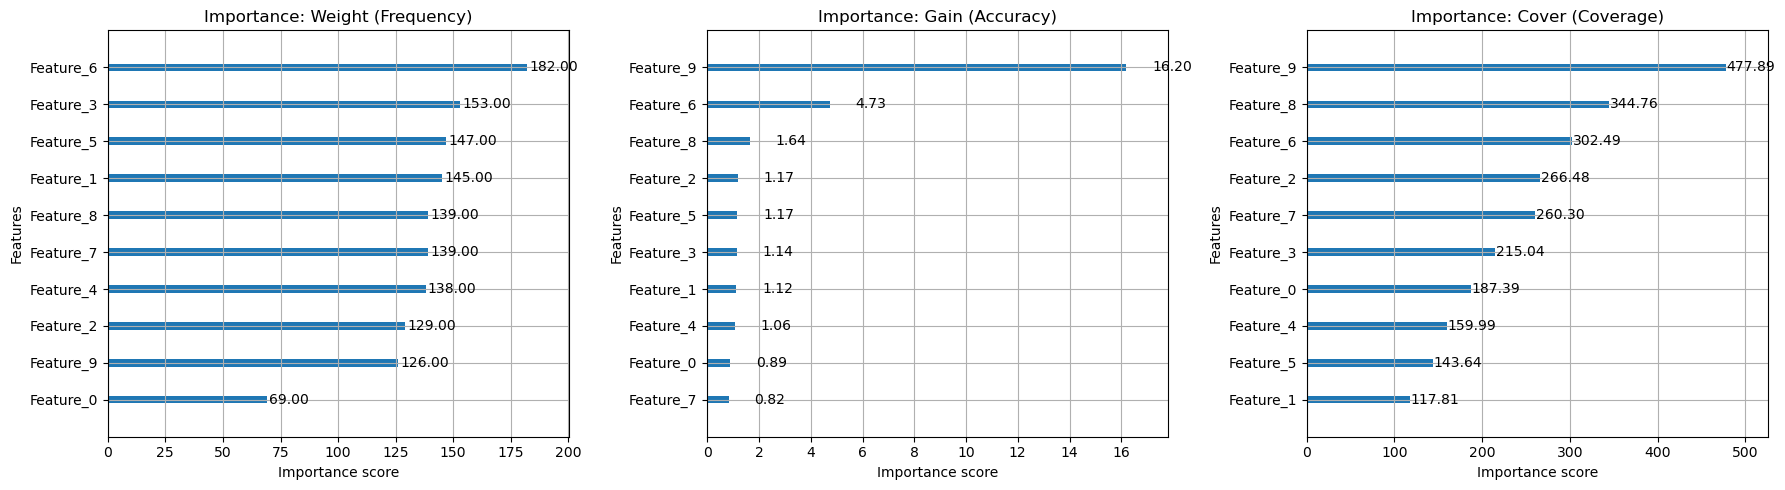

XGBoost Weight Importance: {'Feature_0': 69.0, 'Feature_1': 145.0, 'Feature_2': 129.0, 'Feature_3': 153.0, 'Feature_4': 138.0, 'Feature_5': 147.0, 'Feature_6': 182.0, 'Feature_7': 139.0, 'Feature_8': 139.0, 'Feature_9': 126.0}
XGBoost Gain Importance: {'Feature_0': 0.8887461423873901, 'Feature_1': 1.1152870655059814, 'Feature_2': 1.1726206541061401, 'Feature_3': 1.1364200115203857, 'Feature_4': 1.057886004447937, 'Feature_5': 1.1670631170272827, 'Feature_6': 4.729812145233154, 'Feature_7': 0.824410617351532, 'Feature_8': 1.6388156414031982, 'Feature_9': 16.19597053527832}
XGBoost Cover Importance: {'Feature_0': 187.38970947265625, 'Feature_1': 117.80521392822266, 'Feature_2': 266.4796447753906, 'Feature_3': 215.04364013671875, 'Feature_4': 159.99227905273438, 'Feature_5': 143.63592529296875, 'Feature_6': 302.4909362792969, 'Feature_7': 260.3000183105469, 'Feature_8': 344.761962890625, 'Feature_9': 477.8921203613281}


In [26]:

# 5.2. XGBoost Importances

weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)



### try to use SHAP to find the influencing inputs

In [27]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

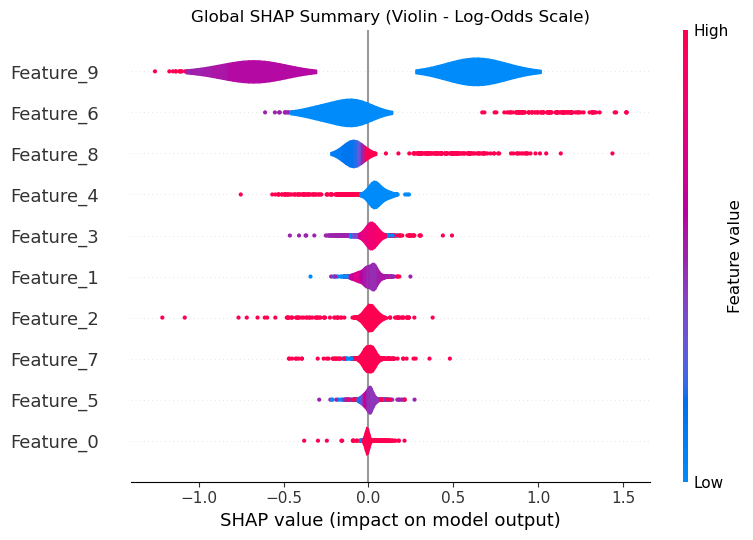

In [28]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


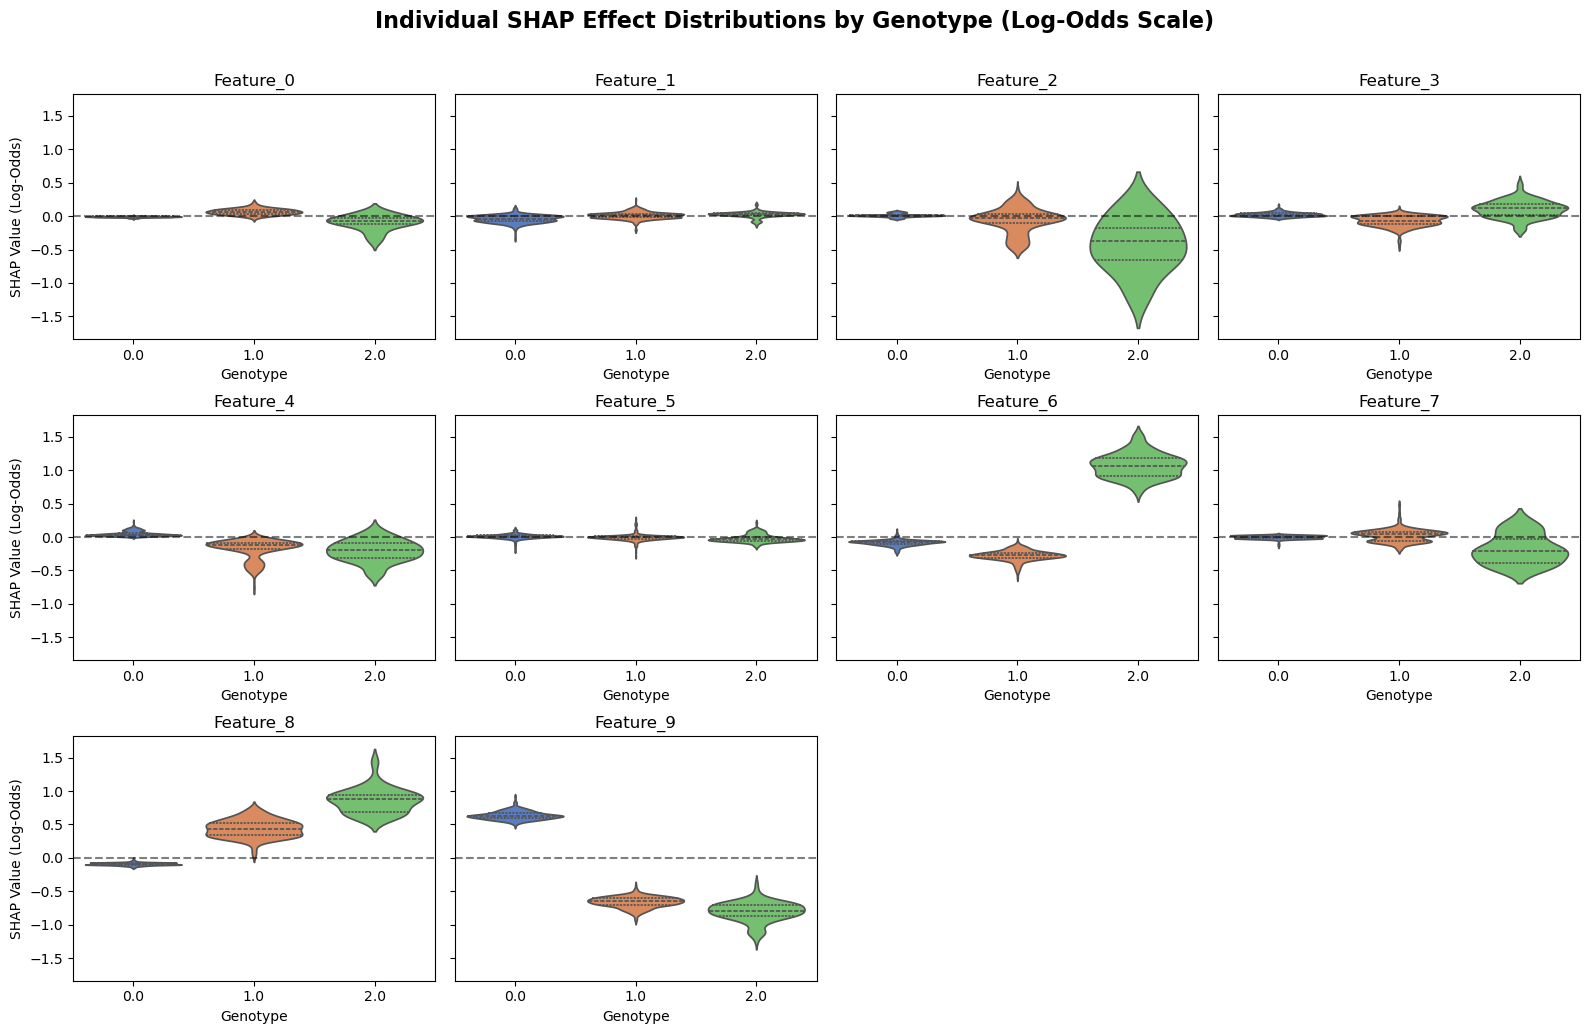

In [29]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


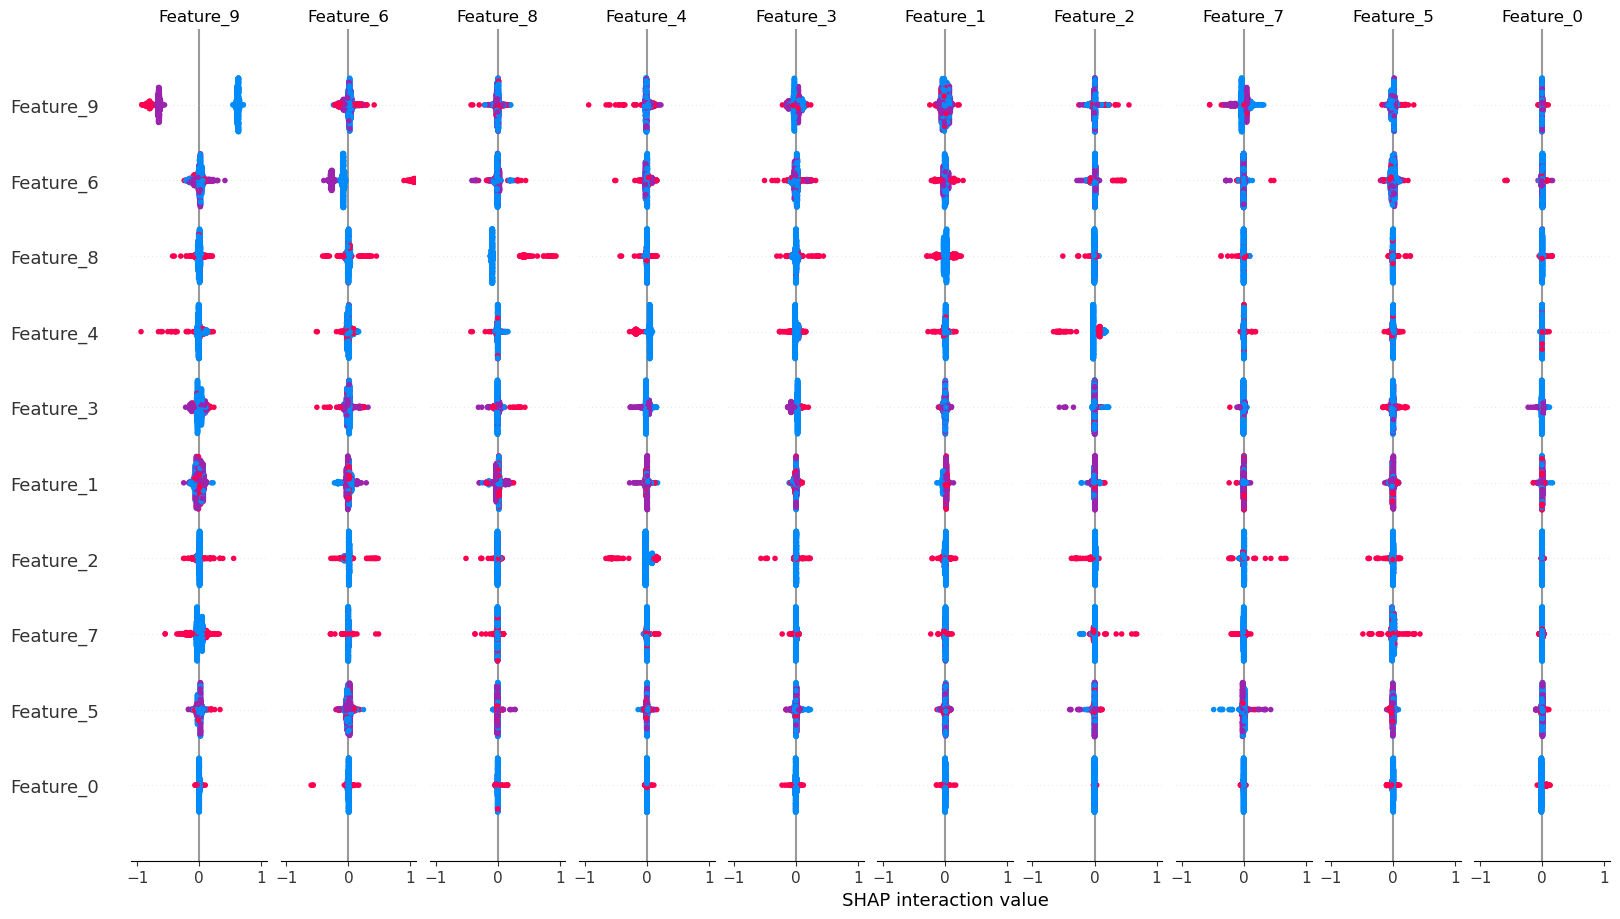


Strongest Interaction found by SHAP: Feature_7 & Feature_9
Plotting pure interaction effect for Feature_7 and Feature_9...


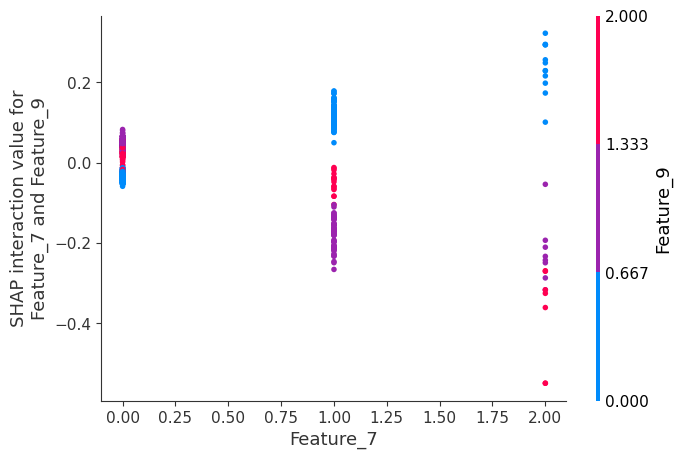


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_7 * Feature_9: 0.062627
  Feature_2 * Feature_4: 0.062360
  Feature_3 * Feature_9: 0.053137
  Feature_6 * Feature_9: 0.048826
  Feature_1 * Feature_9: 0.044237
  Feature_3 * Feature_6: 0.035832
  Feature_1 * Feature_8: 0.035539
  Feature_4 * Feature_9: 0.034064
  Feature_1 * Feature_6: 0.029467
  Feature_3 * Feature_4: 0.029265
-------------------------------------------------

Interaction Effects:
 {'Feature_7 * Feature_9': 0.06262741982936859, 'Feature_2 * Feature_4': 0.06235966831445694, 'Feature_3 * Feature_9': 0.05313703790307045, 'Feature_6 * Feature_9': 0.048825692385435104, 'Feature_1 * Feature_9': 0.04423721134662628, 'Feature_3 * Feature_6': 0.035831596702337265, 'Feature_1 * Feature_8': 0.03553894907236099, 'Feature_4 * Feature_9': 0.03406388685107231, 'Feature_1 * Feature_6': 0.029467295855283737, 'Feature_3 * Feature_4': 0.02926475740969181, 'Feature_5 * Feature_9': 0.029247807338

In [30]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [31]:

# Print numerical ranking
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_9              0.665126     0.0    527   0.636420  0.062226  0.477797  0.595398     0.629388  0.671236  0.917568
Feature_9              0.665126     1.0    349  -0.659367  0.078899 -0.944224 -0.702597    -0.652556 -0.602004 -0.407937
Feature_9              0.665126     2.0    124  -0.803333  0.147287 -1.256664 -0.875985    -0.801146 -0.703478 -0.374157
Feature_6              0.254651     0.0    575  -0.084197  0.043926 -0.251236 -0.105289    -0.077570 -0.060923  0.100881
Feature_6              0.254651     1.0    314  -0.275198  0.075801 -0.608476 -0.307656    -0.274691 -0.233241 -0.066277
Feature_6              0.254651     2.0    111   1.070194  0.179608  0.670016  0.916338     1.063383  1.182152  1.520332
Feature_8              0.153630     0.0    850  -0.089352  0.019778 -0.153790 -0.101946    -0.08